In [26]:
import uproot
import pandas as pd
import numpy as np
import glob


In [27]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [28]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_etaetapip_loose_v7_250122_temp"
cm_elements = ["etahp_13_had_4S_off_v1", "etahp_13_had_4S_v3", "etahp_23_had_4S_off_v1", "etahp_23_had_4S_v1", "etahp_23_had_5Sscan_10657_v1", "etahp_23_had_5Sscan_10706_v1",\
               "etahp_23_had_5Sscan_10751_v1", "etahp_23_had_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [29]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [30]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,6579.000000,6579.000000,6579.000000,6579.000000,6579.000000
mean,1.664143,0.230813,0.444620,1.554958,0.010488
std,0.133609,0.481756,0.441051,0.753027,1.000021
min,1.500020,-0.921561,-0.884499,0.400289,-1.000000
25%,1.576314,-0.172179,0.117068,0.952355,-1.000000
50%,1.632881,0.327410,0.590431,1.458312,1.000000
75%,1.709424,0.650688,0.817940,2.032465,1.000000
max,2.099920,0.992757,0.966454,4.729052,1.000000


In [31]:
df_proc13 = df_proc13.query('Dp_M> 1.73 & Dp_M<2.1')


In [32]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000
mean,1.868458,0.257726,0.461777,1.716519,-0.041429
std,0.135602,0.499930,0.456183,0.814404,0.999498
min,1.730153,-0.895312,-0.884499,0.400610,-1.000000
25%,1.763181,-0.140251,0.129280,1.102828,-1.000000
50%,1.798116,0.370809,0.629191,1.662134,-1.000000
75%,2.040566,0.692616,0.848045,2.202195,1.000000
max,2.099920,0.992757,0.956622,4.729052,1.000000


In [33]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [34]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_241213_temp"
cm_elements = ["15rd_eta_e7_18_4S_v3", "15rd_eta_e20_b26_v1", "15rd_eta_e20_e26_4S_v2", "15rd_eta_e21_5S_scan_v1", "15rd_eta_mori_off_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [35]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [36]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,38323.000000,38323.000000,38323.000000,38323.000000,38323.000000
mean,1.748701,0.295446,0.534781,1.661024,0.000809
std,0.167840,0.459120,0.424569,0.749867,1.000013
min,1.500013,-0.949896,-0.907292,0.400099,-1.000000
25%,1.603372,-0.044318,0.281322,1.078519,-1.000000
50%,1.712259,0.407992,0.690607,1.561495,1.000000
75%,1.895745,0.674889,0.881575,2.128878,1.000000
max,2.099969,0.999848,0.976426,6.740484,1.000000


In [37]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.73 & Dp_M<2.1')


In [38]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,18088.000000,18088.000000,18088.000000,18088.000000,18088.000000
mean,1.903968,0.299411,0.547265,1.696013,-0.002654
std,0.097525,0.458550,0.425985,0.783712,1.000024
min,1.730012,-0.941887,-0.895093,0.400240,-1.000000
25%,1.819513,-0.036094,0.295675,1.092997,-1.000000
50%,1.913657,0.402790,0.709168,1.602649,-1.000000
75%,1.971012,0.678255,0.891823,2.175723,1.000000
max,2.099969,0.999848,0.975377,6.740484,1.000000


In [39]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [40]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity


In [41]:
tree_to_compare = tree_name
plt.rcParams['font.family'] = 'DejaVu Sans'


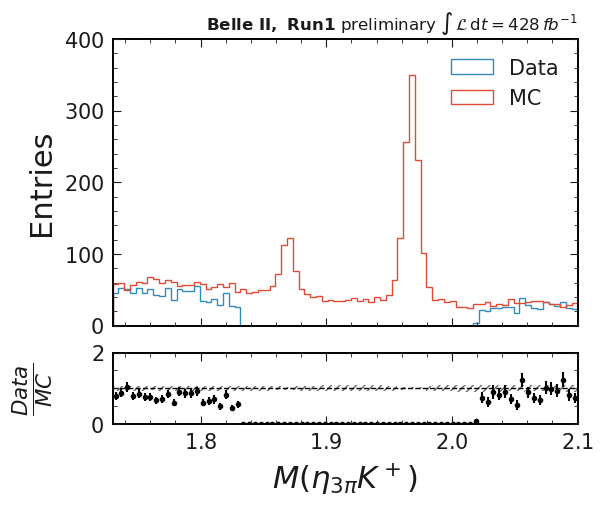

In [44]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{3\pi} K^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.73,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}.png", bbox_inches="tight")